In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

print("Path to dataset files:", path)


100%|██████████| 9.76G/9.76G [05:39<00:00, 30.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4


In [ ]:
import os
from sklearn.metrics import accuracy_score
os.listdir(path)

['test_data_v2', 'test.csv', 'train_data', 'train.csv']

In [ ]:
import pandas as pd
df = pd.read_csv(path+"/train.csv")
df

,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1
...,...,...,...
79945,79945,train_data/9283b107f6274279b6f15bbe77c523aa.jpg,0
79946,79946,train_data/4c6b17fe6dd743428a45773135a10508.jpg,1
79947,79947,train_data/1ccbf96d04e342fd9f629ad55466b29e.jpg,0
79948,79948,train_data/ff960b55f296445abb3c5f304b52e104.jpg,1


In [ ]:

testdf = pd.read_csv(path+"/test.csv")
y = df.label
testdf.id

,id
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg
...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg


In [ ]:
#import cv2_imsho/w
from google.colab.patches import cv2_imshow
df.file_name[0]

'train_data/a6dcb93f596a43249135678dfcfc17ea.jpg'

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
ndArr = cv2.imread(path +"/"+ df.file_name[0])

ndArr = cv2.resize(ndArr, (128, 128))

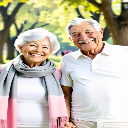

(128, 128, 3)

In [ ]:
cv2_imshow(ndArr)
df.label[0]
ndArr.shape

In [ ]:
# This stacks all red, then all green, then all blue values
import numpy as np
one_d_array = np.concatenate([ndArr[:,:,0].flatten(),
                             ndArr[:,:,1].flatten(),
                             ndArr[:,:,2].flatten()])
print(one_d_array)

[ 74  51  51 ... 251 249 252]


In [ ]:
input = []
for x in df.file_name:
  loc = path+"/" + x
  num = cv2.imread(loc)
  num = cv2.resize(num, (128, 128))
  one_d = np.concatenate([num[:,:,0].flatten(), num[:,:,1].flatten(),num[:,:,2].flatten()])
  input.append(one_d)
train_data = np.array(input)
print(f"Input array shape: {train_data.shape}")



Input array shape: (79950, 49152)


In [ ]:
input = []
for x in df.file_name.iloc[:5000]:
  loc = path+"/" + x
  num = cv2.imread(loc)
  num = cv2.resize(num, (128, 128))
  one_d = np.concatenate([num[:,:,0].flatten(), num[:,:,1].flatten(),num[:,:,2].flatten()])
  input.append(one_d)
first_fiveK = np.array(input)
print(f"Input array shape: {first_fiveK.shape}")


Input array shape: (5000, 49152)


In [ ]:
input = []
for x in testdf.id:
  loc = path + "/" + x
  num = cv2.imread(loc)
  num = cv2.resize(num, (128, 128))
  one_d = np.concatenate([num[:,:,0].flatten(), num[:,:,1].flatten(),num[:,:,2].flatten()])
  input.append(one_d)
test_data = np.array(input)
print(f"Input array shape: {test_data.shape}")


Input array shape: (5540, 49152)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

class PatchCraftDataset(Dataset):
    def __init__(self, images, labels, img_size=128, patch_size=64, num_patches=5):
        """
        Args:
            images: Array of flattened RGB values (num_images, 128*128*3)
            labels: Corresponding labels (0=real, 1=AI)
            img_size: Size of input images (assumed square)
            patch_size: Size of square patches to extract
            num_patches: Number of patches to extract per image
        """
        self.images = images
        self.labels = labels
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches

        # Validate input shape
        expected_size = img_size * img_size * 3
        assert images.shape[1] == expected_size, \
            f"Input shape mismatch: Expected {expected_size}, got {images.shape[1]}"

    def __len__(self):
        return len(self.images) * self.num_patches

    def __getitem__(self, idx):
        img_idx = idx // self.num_patches
        patch_idx = idx % self.num_patches

        # Get the original image and reshape to (3, 128, 128)
        img_flat = self.images[img_idx]
        img_3d = img_flat.reshape(3, self.img_size, self.img_size).astype(np.float32) / 255.0

        # Extract random patch (same for all patches in this image)
        np.random.seed(img_idx)  # Consistent patches per image
        max_pos = self.img_size - self.patch_size
        x = np.random.randint(0, max_pos)
        y = np.random.randint(0, max_pos)

        patch = img_3d[:, x:x+self.patch_size, y:y+self.patch_size]

        label = self.labels[img_idx]

        return torch.from_numpy(patch.copy()), torch.tensor(label, dtype=torch.long)

class PatchCraftDetector(nn.Module):
    def __init__(self, patch_size=64):
        super(PatchCraftDetector, self).__init__()
        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Flatten()
        )

        # Dynamically calculate feature size
        with torch.no_grad():
            dummy = torch.zeros(1, 3, patch_size, patch_size)
            dummy_out = self.features(dummy)
            in_features = dummy_out.size(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def train_patchcraft(images, labels, img_size=128, patch_size=64, num_patches=5, batch_size=64, epochs=30):
    """
    Train the PatchCraft model

    Args:
        images: Array of flattened RGB values (n_samples, 128*128*3)
        labels: Array of labels (n_samples,)
        img_size: Size of input images (default 128)
        patch_size: Size of patches to extract (default 64)
        num_patches: Number of patches per image (default 5)
        batch_size: Training batch size (default 64)
        epochs: Number of training epochs (default 30)
    """
    # Create dataset
    dataset = PatchCraftDataset(
        images=images,
        labels=labels,
        img_size=img_size,
        patch_size=patch_size,
        num_patches=num_patches
    )

    # Split dataset (80% train, 20% validation)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # Initialize model, loss, and optimizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PatchCraftDetector(patch_size=patch_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

    # Training loop
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Update scheduler
        scheduler.step(val_acc)

        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {epoch_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Acc: {val_acc:.4f} | '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'history': history
            }, 'best_patchcraft_model.pth')

    print(f'Training complete. Best validation accuracy: {best_val_acc:.4f}')
    return model, history

# Example usage:
# Assuming:
#   All: numpy array of shape (num_images, 128*128*3) with flattened RGB values
#   y: numpy array of shape (num_images,) with labels (0=real, 1=AI)
#
# model, history = train_patchcraft(
#     images=All,
#     labels=y,
#     img_size=128,
#     patch_size=64,
#     num_patches=5,
#     batch_size=64,
#     epochs=30
# )

def predict_image(model, image_flat, img_size=128, patch_size=64, num_patches=10, device='cpu'):
    """
    Predict whether an image is AI-generated using patch-based voting

    Args:
        model: Trained PatchCraft model
        image_flat: Flattened image array (128*128*3,)
        img_size: Image size (default 128)
        patch_size: Patch size (default 64)
        num_patches: Number of patches to sample (default 10)
        device: Device to use for inference

    Returns:
        is_ai: True if classified as AI-generated
        confidence: Confidence score (0-1)
    """
    model.eval()
    model.to(device)

    # Reshape and normalize
    img_3d = image_flat.reshape(3, img_size, img_size).astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_3d)

    # Extract patches
    patches = []
    max_pos = img_size - patch_size
    for _ in range(num_patches):
        x = np.random.randint(0, max_pos)
        y = np.random.randint(0, max_pos)
        patch = img_tensor[:, x:x+patch_size, y:y+patch_size]
        patches.append(patch)

    patches = torch.stack(patches).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(patches)
        probs = torch.softmax(outputs, dim=1)
        ai_probs = probs[:, 1].cpu().numpy()

    confidence = np.mean(ai_probs)
    is_ai = confidence > 0.5

    return is_ai, confidence

In [ ]:
# Assuming:
#   All: numpy array of shape (num_images, 128*128*3)
#   y: numpy array of shape (num_images,) with labels (0=real, 1=AI)

model, history = train_patchcraft(
    images=train_data,
    labels=y,
    img_size=128,
    patch_size=64,   # Can be 32, 64, or other sizes < 128
    num_patches=5,   # Number of patches per image during training
    batch_size=64,
    epochs=30
)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/30: Train Loss: 0.2328 | Val Loss: 0.1609 | Val Acc: 0.9379 | LR: 0.001000


In [ ]:
is_ai, confidence = predict_image(model, one_d_array)

# To predict a new image:
#   image_flat: flattened array of a single 128x128 image (49152 elements)
print(is_ai, confidence)

In [ ]:
y_pred = []

for stuff in test_data:
    # Predict using patch voting
    is_ai, confidence = predict_image(model, stuff)
    y_pred.append(int(is_ai))  # Convert bool to 0/1

# Calculate accuracy
print(y_pred)

In [ ]:
from google.colab import files

def export_predictions(labels):
    assert len(labels) == 5540, f'You have {len(labels)} predictions but should have 5540'
    df = pd.DataFrame({'id': np.arange(5540) + 1, 'label': labels})
    df.to_csv('predictions.csv', index=False)
    files.download('predictions.csv')

In [ ]:
bababo = []

for stuff in first_fiveK:
    # Predict using patch voting
    is_ai, confidence = predict_image(model, stuff)
    bababo.append(int(is_ai))  # Convert bool to 0/1

# Calculate accuracy
print(bababo)
accuracy_score(bababo, df.label[:5000])

In [ ]:
import torch
from google.colab import files

# Save the model state dictionary
torch.save(model.state_dict(), 'patchcraft_model_state_dict.pth')

print("Model state dictionary saved successfully (patchcraft_model_state_dict.pth).")
print("You can load this model in another notebook for inference using:")
print("""
# Initialize the model with the same architecture
loaded_model = PatchCraftDetector(patch_size=64) # Make sure patch_size matches your trained model

# Load the saved state dictionary
loaded_model.load_state_dict(torch.load('patchcraft_model_state_dict.pth'))

# Set the model to evaluation mode
loaded_model.eval()

print("Model loaded successfully!")
""")

# Optionally download the file
files.download('patchcraft_model_state_dict.pth')